# Heart Attack Risk Classification
### Prediksi Risiko Serangan Jantung Menggunakan Machine Learning

**Author:** Daffa Kumara Khiar Faisa


## 1. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
np.random.seed(42)


In [2]:
data = pd.read_csv('heart_attack.csv', header=0)
data.columns = ['age', 'gender', 'impulse', 'pressure_high', 'pressure_low', 'glucose', 'kcm', 'troponin', 'class']

print("Jumlah baris dan kolom:", data.shape)
data.head()


Jumlah baris dan kolom: (1319, 9)


,age,gender,impulse,pressure_high,pressure_low,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [3]:
print("=== INFORMASI DATASET ===")
data.info()
print("\n=== MISSING VALUES ===")
print(data.isnull().sum())
print("\n=== DUPLIKAT ===")
print("Jumlah baris duplikat:", data.duplicated().sum())


=== INFORMASI DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impulse        1319 non-null   int64  
 3   pressure_high  1319 non-null   int64  
 4   pressure_low   1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   str    
dtypes: float64(3), int64(5), str(1)
memory usage: 92.9 KB

=== MISSING VALUES ===
age              0
gender           0
impulse          0
pressure_high    0
pressure_low     0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

=== DUPLIKAT ===
Jumlah baris duplikat: 0


## 2. Data Cleaning

### 2.1 Penanganan Anomali pada `impulse`

Nilai denyut nadi manusia normal berada di kisaran puluhan hingga ratusan bpm, namun tidak pernah mencapai ribuan. Ditemukan **3 baris** dengan `impulse = 1111`, yang secara medis mustahil dan merupakan indikasi kuat *data entry error*. Nilai ini diperlakukan sebagai *missing value* lalu diimputasi menggunakan median, karena jumlahnya sangat kecil (3 dari 1319 baris) sehingga median imputation aman digunakan tanpa mendistorsi distribusi data.


In [4]:
print("Jumlah baris dengan impulse = 1111:", (data['impulse'] == 1111).sum())
data.loc[data['impulse'] == 1111, 'impulse'] = np.nan

median_impulse = data['impulse'].median()
data['impulse'] = data['impulse'].fillna(median_impulse)

print(f"Nilai impulse diimputasi dengan median: {median_impulse}")
print("Jumlah missing values setelah imputasi:", data['impulse'].isnull().sum())


Jumlah baris dengan impulse = 1111: 3
Nilai impulse diimputasi dengan median: 74.0
Jumlah missing values setelah imputasi: 0


In [5]:
le = LabelEncoder()
data['class_encoded'] = le.fit_transform(data['class'])  # negative -> 0, positive -> 1
print("Mapping label:", dict(zip(le.classes_, le.transform(le.classes_))))


Mapping label: {'negative': np.int64(0), 'positive': np.int64(1)}


### 2.2 Catatan mengenai Outlier Lainnya

Selain `impulse`, ditemukan nilai `pressure_high` minimum sebesar 42 mmHg (kondisi hipotensi ekstrem). Berbeda dengan kasus `impulse = 1111`, nilai ini **masih berada dalam rentang yang secara klinis mungkin terjadi** (meski jarang), sehingga tidak diperlakukan sebagai data error. Outlier jenis ini ditangani melalui IQR capping pada tahap pipeline modeling (bukan dihapus), agar variasi ekstrem tetap tersimpan namun tidak mendominasi training.


## 3. Exploratory Data Analysis (EDA)

/tmp/ipykernel_645/2341603809.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=data, palette='Set2')


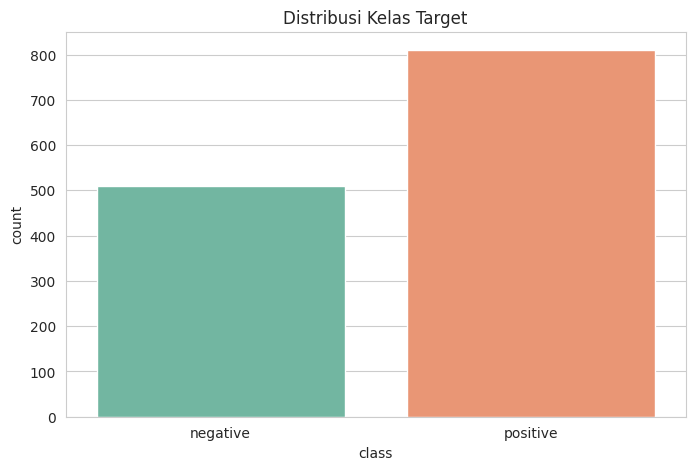

Persentase kelas target:
class
positive    61.410159
negative    38.589841
Name: proportion, dtype: float64


In [6]:
numerical_columns = ['age', 'impulse', 'pressure_high', 'pressure_low', 'glucose', 'kcm', 'troponin']

plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=data, palette='Set2')
plt.title('Distribusi Kelas Target')
plt.show()

print("Persentase kelas target:")
print(data['class'].value_counts(normalize=True) * 100)


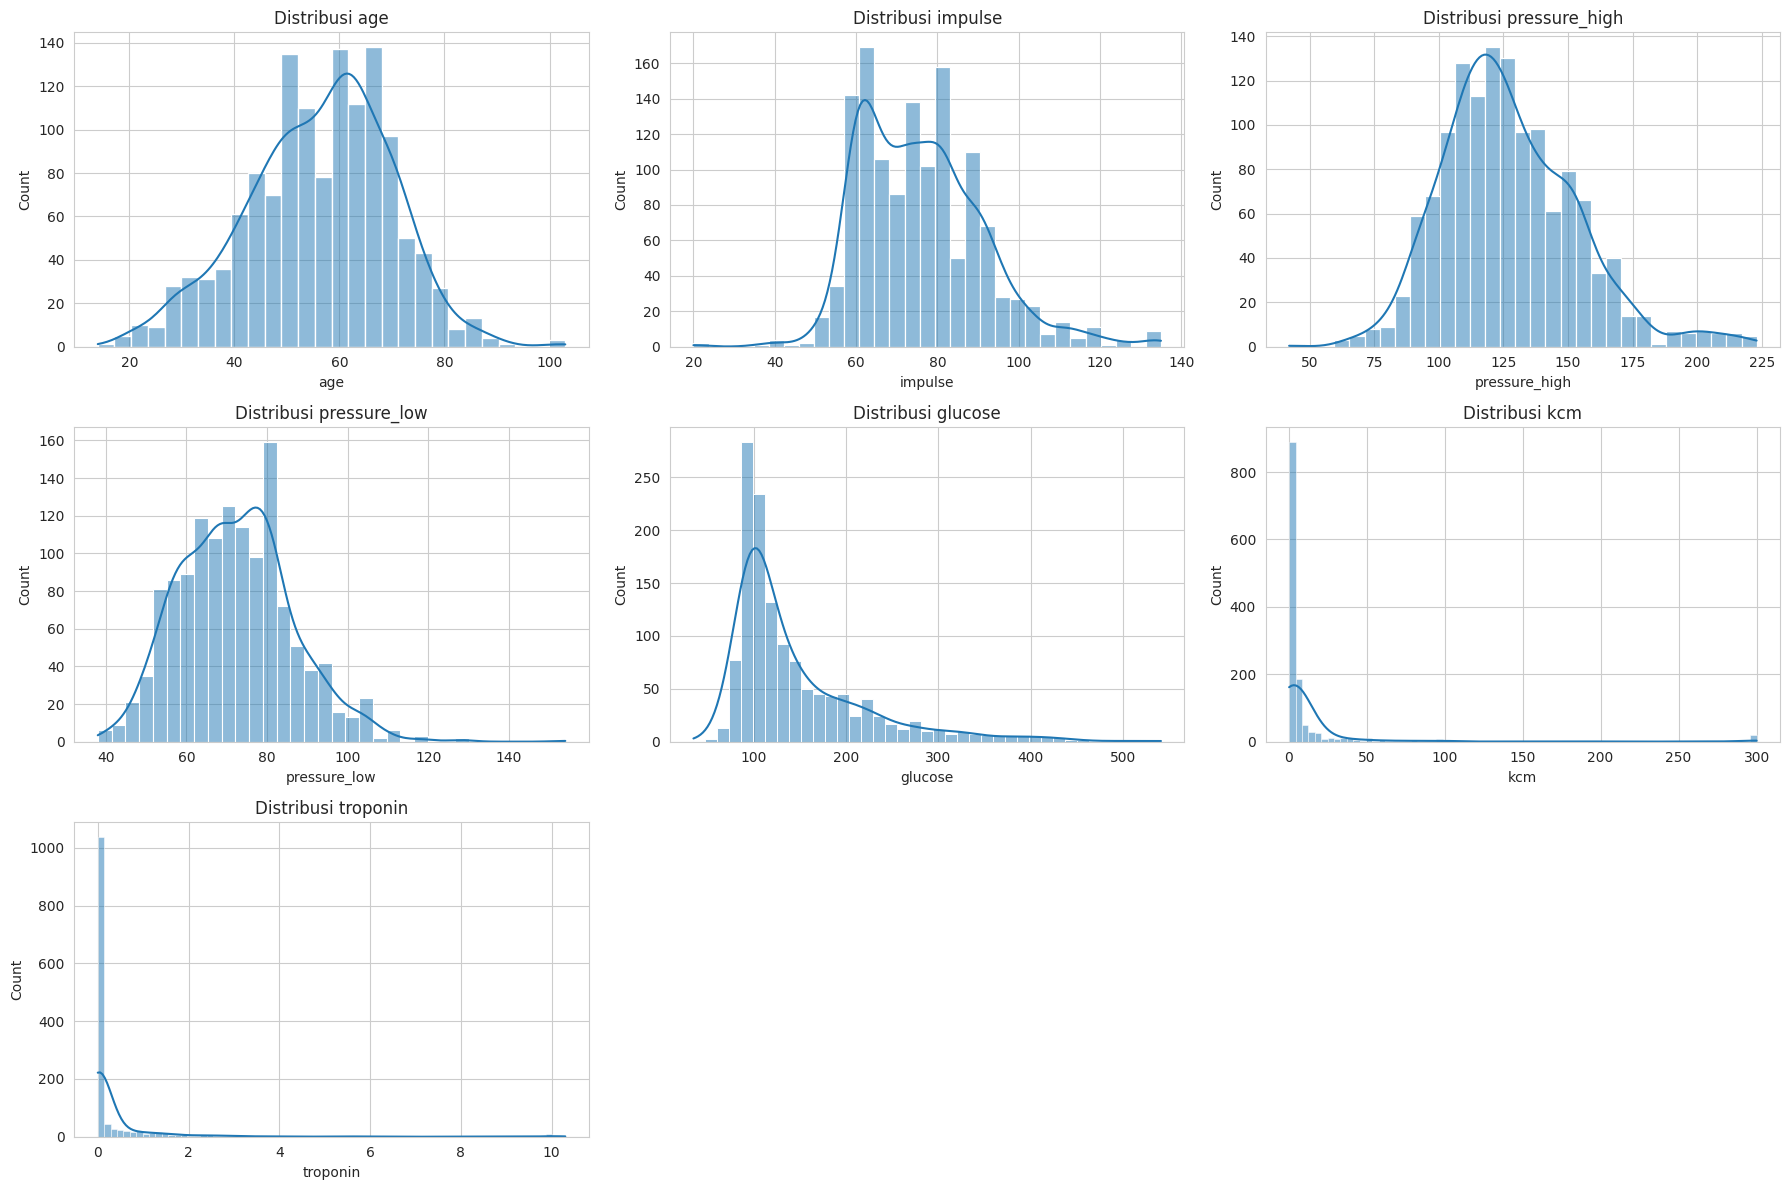

In [7]:
plt.figure(figsize=(18, 12))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()


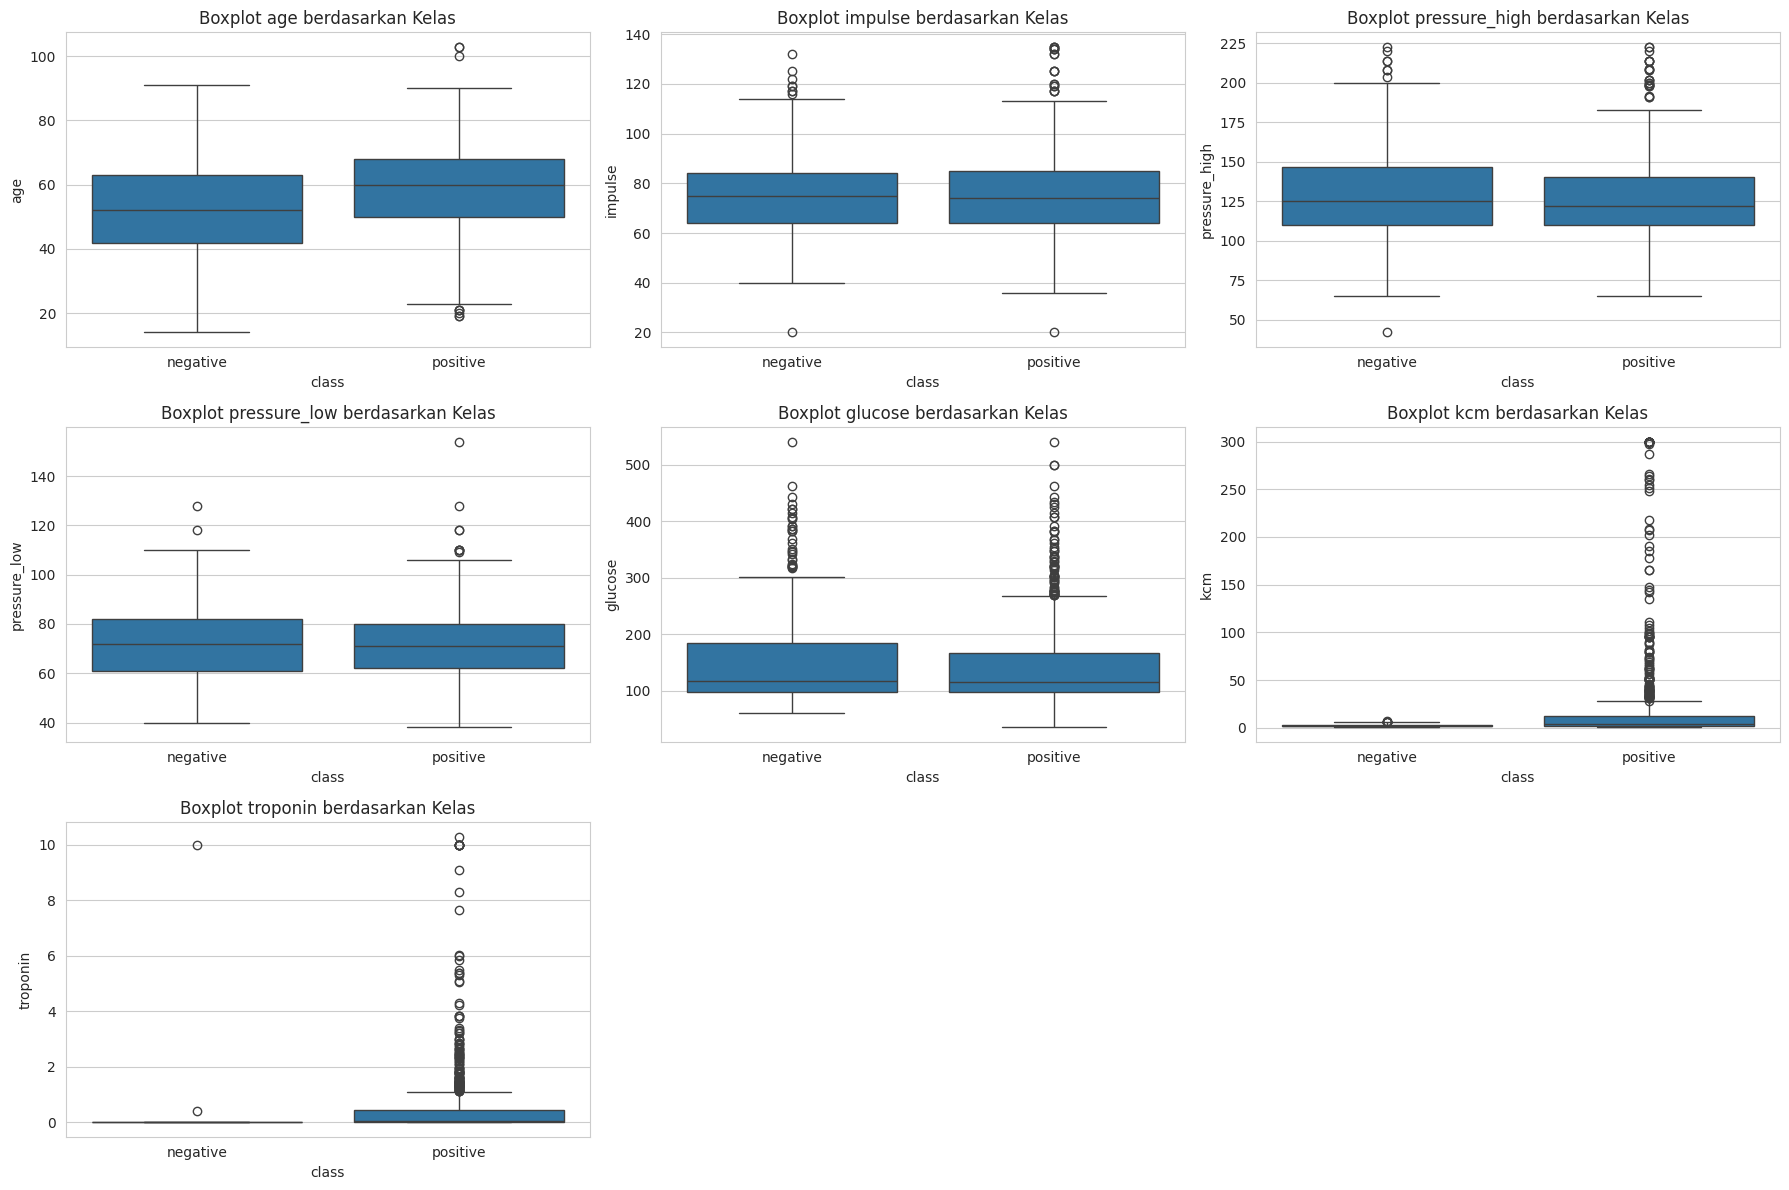

In [8]:
plt.figure(figsize=(18, 12))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='class', y=column, data=data)
    plt.title(f'Boxplot {column} berdasarkan Kelas')
plt.tight_layout()
plt.show()


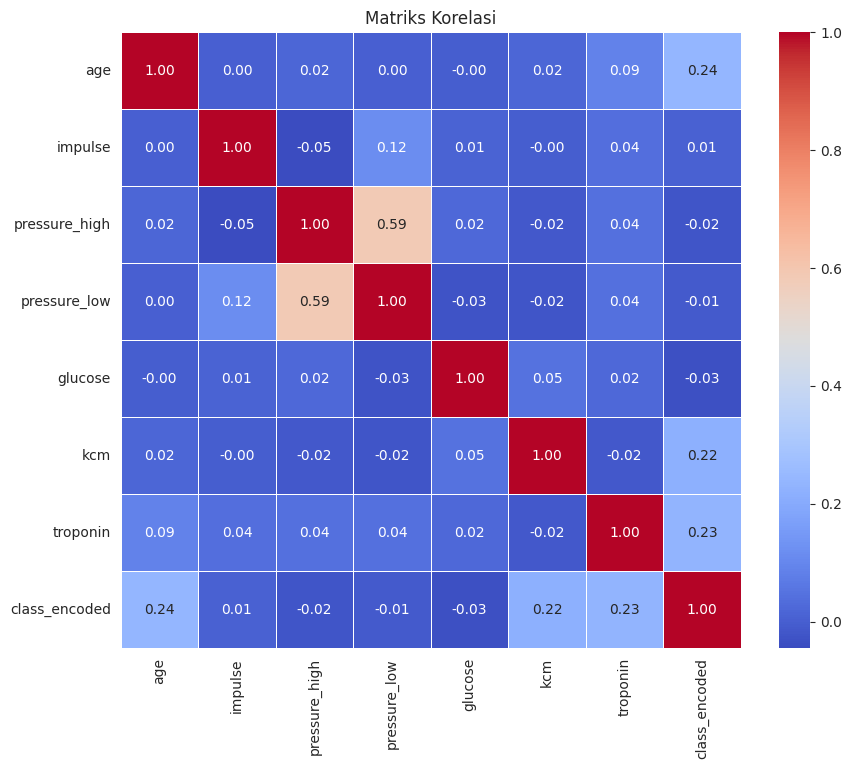

In [9]:
correlation_matrix = data[numerical_columns + ['class_encoded']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi')
plt.show()


In [10]:
print("=== UJI STATISTIK (Independent t-test) ===")
print("H0: Tidak ada perbedaan rata-rata antara kelas positive dan negative\n")
for column in numerical_columns:
    pos = data[data['class'] == 'positive'][column]
    neg = data[data['class'] == 'negative'][column]
    t_stat, p_value = stats.ttest_ind(pos, neg)
    sig = "Signifikan" if p_value < 0.05 else "Tidak Signifikan"
    print(f"{column:15s} | mean(+)={pos.mean():8.2f} | mean(-)={neg.mean():8.2f} | p-value={p_value:.4e} | {sig}")


=== UJI STATISTIK (Independent t-test) ===
H0: Tidak ada perbedaan rata-rata antara kelas positive dan negative

age             | mean(+)=   58.77 | mean(-)=   52.09 | p-value=1.8616e-18 | Signifikan
impulse         | mean(+)=   76.06 | mean(-)=   75.85 | p-value=8.0739e-01 | Tidak Signifikan
pressure_high   | mean(+)=  126.74 | mean(-)=  127.86 | p-value=4.4984e-01 | Tidak Signifikan
pressure_low    | mean(+)=   72.16 | mean(-)=   72.44 | p-value=7.2598e-01 | Tidak Signifikan
glucose         | mean(+)=  144.67 | mean(-)=  149.76 | p-value=2.3020e-01 | Tidak Signifikan
kcm             | mean(+)=   23.27 | mean(-)=    2.56 | p-value=1.2878e-15 | Signifikan
troponin        | mean(+)=    0.57 | mean(-)=    0.03 | p-value=3.3032e-17 | Signifikan


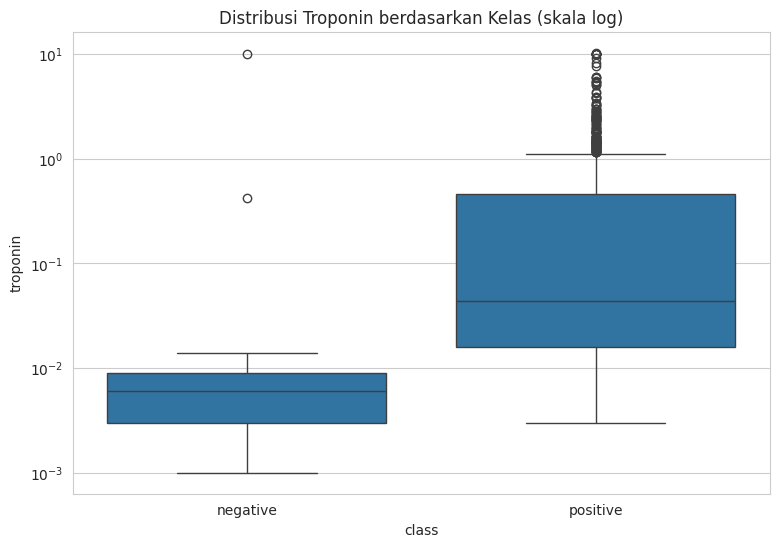

In [11]:
plt.figure(figsize=(9, 6))
sns.boxplot(x='class', y='troponin', data=data)
plt.yscale('log')
plt.title('Distribusi Troponin berdasarkan Kelas (skala log)')
plt.show()


## 4. Modeling

### 4.1 Train-Test Split & Preprocessing Pipeline

**Perbaikan penting dari versi sebelumnya:** seluruh proses *fitting* (menentukan batas outlier, menghitung mean/std untuk scaling, memilih fitur terbaik) hanya dilakukan pada **training set**. Test set hanya melalui proses *transform* menggunakan parameter yang sudah dipelajari dari training set. Ini mencegah *data leakage* — kebocoran informasi dari test set ke proses training yang bisa membuat evaluasi model jadi terlalu optimis dan tidak representatif terhadap performa di data baru.


In [12]:
feature_columns = ['age', 'gender', 'impulse', 'pressure_high', 'pressure_low', 'glucose', 'kcm', 'troponin']
X = data[feature_columns]
y = data['class_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nDistribusi kelas di train:")
print(y_train.value_counts(normalize=True))
print("\nDistribusi kelas di test:")
print(y_test.value_counts(normalize=True))


Train shape: (1055, 8)  Test shape: (264, 8)

Distribusi kelas di train:
class_encoded
1    0.614218
0    0.385782
Name: proportion, dtype: float64

Distribusi kelas di test:
class_encoded
1    0.613636
0    0.386364
Name: proportion, dtype: float64


In [13]:
# Outlier capping (IQR) - bounds dihitung HANYA dari training set
outlier_bounds = {}
for column in feature_columns:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    outlier_bounds[column] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

def apply_outlier_capping(df, bounds):
    df = df.copy()
    for column, (lower, upper) in bounds.items():
        df[column] = df[column].clip(lower=lower, upper=upper)
    return df

X_train_capped = apply_outlier_capping(X_train, outlier_bounds)
X_test_capped = apply_outlier_capping(X_test, outlier_bounds)  # pakai bounds dari train, bukan dihitung ulang

print("Outlier bounds (dihitung dari training set):")
for col, (low, high) in outlier_bounds.items():
    print(f"  {col:15s}: [{low:.2f}, {high:.2f}]")


Outlier bounds (dihitung dari training set):
  age            : [20.00, 92.00]
  gender         : [-1.50, 2.50]
  impulse        : [30.00, 118.00]
  pressure_high  : [59.00, 195.00]
  pressure_low   : [32.50, 108.50]
  glucose        : [-11.00, 277.00]
  kcm            : [-4.15, 11.29]
  troponin       : [-0.13, 0.23]


In [14]:
# Scaling - fit HANYA di training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_capped)
X_test_scaled = scaler.transform(X_test_capped)

print("Scaling selesai. Shape train:", X_train_scaled.shape, " test:", X_test_scaled.shape)


Scaling selesai. Shape train: (1055, 8)  test: (264, 8)


### 4.2 Feature Selection

Feature selection (SelectKBest) juga di-*fit* hanya pada training set. Fitur yang terpilih di sini akan **konsisten dipakai** di seluruh tahap berikutnya — tuning, evaluasi, dan testing pasien baru — untuk menghindari mismatch seperti pada versi sebelumnya.


In [15]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    'Feature': feature_columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print("Feature Scores (F-statistic):")
print(feature_scores)

# Pilih 5 fitur teratas
TOP_K = 5
top_features = feature_scores.head(TOP_K)['Feature'].tolist()
top_feature_idx = [feature_columns.index(f) for f in top_features]
print(f"\nTop {TOP_K} fitur terpilih:", top_features)


Feature Scores (F-statistic):
         Feature       Score
7       troponin  386.957735
6            kcm  172.127418
0            age   64.068508
1         gender    8.601895
5        glucose    1.626403
3  pressure_high    0.377603
2        impulse    0.006930
4   pressure_low    0.001145

Top 5 fitur terpilih: ['troponin', 'kcm', 'age', 'gender', 'glucose']


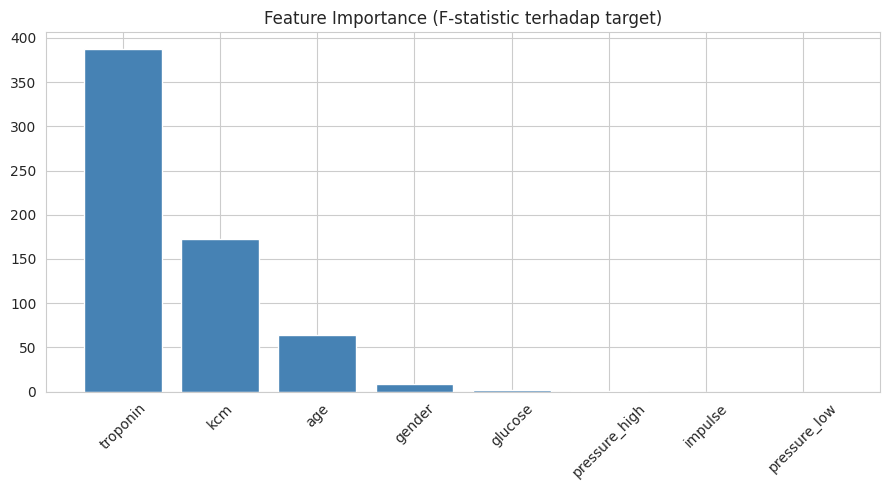

In [16]:
plt.figure(figsize=(9, 5))
plt.bar(feature_scores['Feature'], feature_scores['Score'], color='steelblue')
plt.title('Feature Importance (F-statistic terhadap target)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
X_train_selected = X_train_scaled[:, top_feature_idx]
X_test_selected = X_test_scaled[:, top_feature_idx]

print("Shape data setelah feature selection - train:", X_train_selected.shape, " test:", X_test_selected.shape)


Shape data setelah feature selection - train: (1055, 5)  test: (264, 5)


### 4.3 Hyperparameter Tuning (GridSearchCV)

Ketiga model di-tuning menggunakan data **training yang sudah melalui feature selection** (`X_train_selected`). Model hasil tuning inilah yang nantinya dipakai secara konsisten untuk evaluasi maupun testing pasien baru — tidak ada model "bayangan" yang dilatih terpisah.


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=cv, scoring='recall', n_jobs=-1)
rf_grid.fit(X_train_selected, y_train)
print("Random Forest - Best Params:", rf_grid.best_params_)


Random Forest - Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [19]:
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(SVC(random_state=42, probability=True), svm_param_grid, cv=cv, scoring='recall', n_jobs=-1)
svm_grid.fit(X_train_selected, y_train)
print("SVM - Best Params:", svm_grid.best_params_)


SVM - Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}


In [20]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=cv, scoring='recall', n_jobs=-1)
knn_grid.fit(X_train_selected, y_train)
print("KNN - Best Params:", knn_grid.best_params_)


KNN - Best Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


**Catatan pemilihan metrik tuning:** GridSearchCV dioptimalkan menggunakan **recall** (bukan accuracy) sebagai *scoring metric*. Dalam konteks skrining risiko serangan jantung, *false negative* (pasien berisiko yang diprediksi aman) jauh lebih berbahaya dibanding *false positive* (pasien aman yang diprediksi berisiko lalu diperiksa ulang). Recall yang tinggi memastikan model meminimalkan kasus pasien berisiko yang terlewat.


### 4.4 Evaluasi Model

Evaluasi dilakukan pada `X_test_selected` — data test yang belum pernah dilihat model sama sekali selama proses training maupun tuning. Selain accuracy, ditampilkan juga confusion matrix, precision/recall/F1 per kelas, dan ROC-AUC, karena pada konteks medis, accuracy saja bisa menyesatkan (terutama jika model justru sering salah pada kelas positive).


In [21]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc, 'model': model}


=== Random Forest ===
Accuracy : 0.9848
Precision: 0.9877
Recall   : 0.9877
F1-Score : 0.9877
ROC-AUC  : 0.9925

Classification Report:
              precision    recall  f1-score   support

    negative       0.98      0.98      0.98       102
    positive       0.99      0.99      0.99       162

    accuracy                           0.98       264
   macro avg       0.98      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264



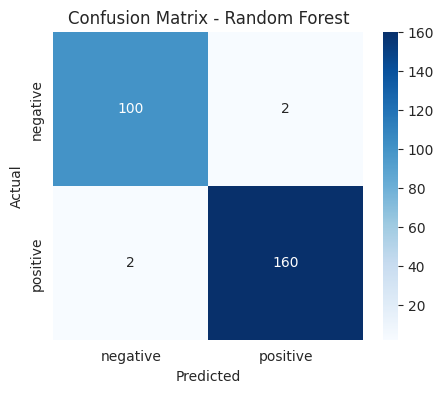

In [22]:
results = []
results.append(evaluate_model("Random Forest", rf_grid.best_estimator_, X_test_selected, y_test))


=== SVM ===
Accuracy : 0.9432
Precision: 0.9682
Recall   : 0.9383
F1-Score : 0.9530
ROC-AUC  : 0.9805

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.95      0.93       102
    positive       0.97      0.94      0.95       162

    accuracy                           0.94       264
   macro avg       0.94      0.94      0.94       264
weighted avg       0.94      0.94      0.94       264



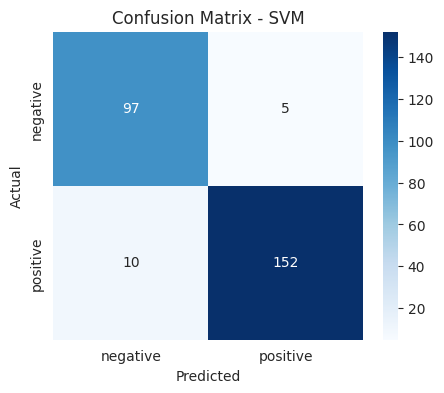

In [23]:
results.append(evaluate_model("SVM", svm_grid.best_estimator_, X_test_selected, y_test))


=== KNN ===
Accuracy : 0.9205
Precision: 0.9608
Recall   : 0.9074
F1-Score : 0.9333
ROC-AUC  : 0.9575

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.94      0.90       102
    positive       0.96      0.91      0.93       162

    accuracy                           0.92       264
   macro avg       0.91      0.92      0.92       264
weighted avg       0.92      0.92      0.92       264



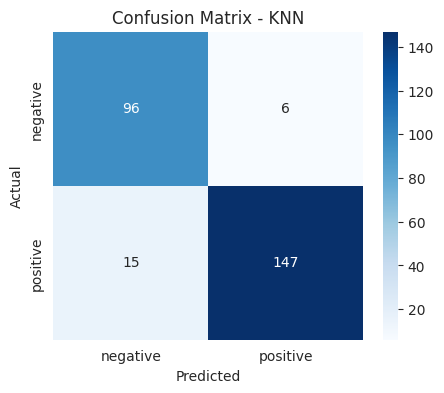

In [24]:
results.append(evaluate_model("KNN", knn_grid.best_estimator_, X_test_selected, y_test))


=== RINGKASAN PERBANDINGAN MODEL ===
               accuracy  precision  recall      f1     auc
name                                                      
Random Forest    0.9848     0.9877  0.9877  0.9877  0.9925
SVM              0.9432     0.9682  0.9383  0.9530  0.9805
KNN              0.9205     0.9608  0.9074  0.9333  0.9575


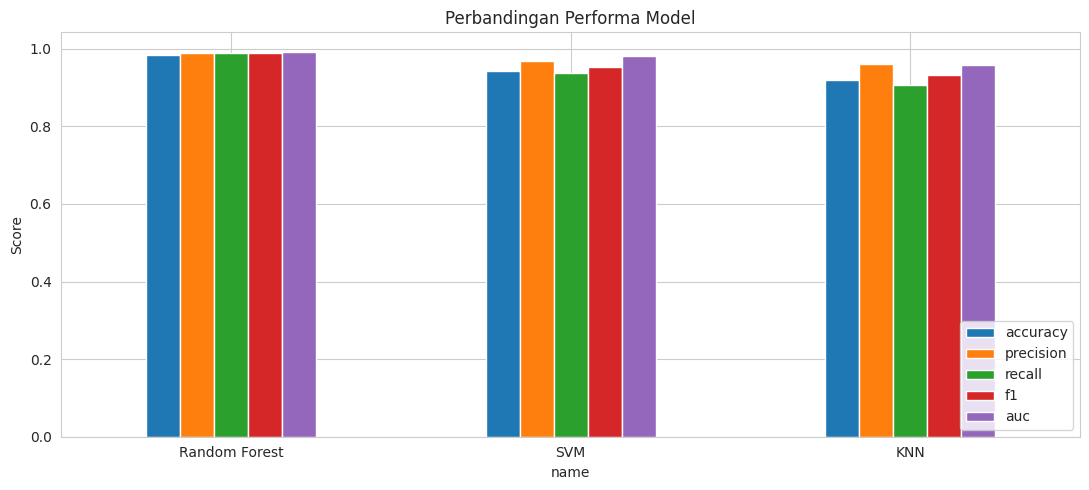

In [25]:
results_df = pd.DataFrame(results).drop(columns='model').set_index('name')
print("=== RINGKASAN PERBANDINGAN MODEL ===")
print(results_df.round(4))

results_df.plot(kind='bar', figsize=(11, 5))
plt.title('Perbandingan Performa Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


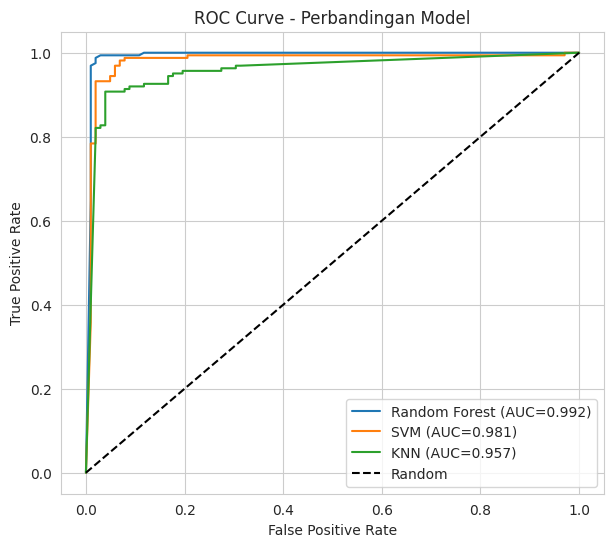

In [26]:
plt.figure(figsize=(7, 6))
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['model'].predict_proba(X_test_selected)[:, 1])
    plt.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Perbandingan Model')
plt.legend()
plt.show()


In [27]:
# Model terbaik dipilih berdasarkan recall (paling relevan untuk konteks medis),
# dengan F1-score sebagai tie-breaker
best_result = max(results, key=lambda r: (r['recall'], r['f1']))
best_model = best_result['model']

print(f"BEST MODEL: {best_result['name']}")
print(f"Recall   : {best_result['recall']:.4f}")
print(f"F1-Score : {best_result['f1']:.4f}")
print(f"Accuracy : {best_result['accuracy']:.4f}")
print(f"ROC-AUC  : {best_result['auc']:.4f}")


BEST MODEL: Random Forest
Recall   : 0.9877
F1-Score : 0.9877
Accuracy : 0.9848
ROC-AUC  : 0.9925


## 5. Testing pada Data Pasien Baru

Testing memakai **`best_model`** yang sama persis dengan model yang di-tuning dan dievaluasi sebelumnya (Random Forest) — bukan model terpisah. Data pasien baru melewati **pipeline preprocessing yang identik**: outlier capping (pakai bounds dari training set) → scaling (pakai scaler dari training set) → feature selection (pakai fitur terpilih yang sama).


In [28]:
def preprocess_new_patient(raw_data_dict, feature_columns, outlier_bounds, scaler, top_feature_idx):
    """
    raw_data_dict: dict fitur -> nilai, mengikuti urutan feature_columns
    Mengaplikasikan pipeline preprocessing yang identik dengan training.
    """
    df_new = pd.DataFrame([raw_data_dict], columns=feature_columns)
    df_capped = apply_outlier_capping(df_new, outlier_bounds)
    scaled = scaler.transform(df_capped)
    return scaled[:, top_feature_idx]


new_patients = [
    {'age': 64, 'gender': 1, 'impulse': 66, 'pressure_high': 160, 'pressure_low': 83, 'glucose': 160.0, 'kcm': 1.80, 'troponin': 0.012},
    {'age': 55, 'gender': 0, 'impulse': 70, 'pressure_high': 140, 'pressure_low': 75, 'glucose': 120.0, 'kcm': 2.50, 'troponin': 0.008},
    {'age': 45, 'gender': 1, 'impulse': 75, 'pressure_high': 130, 'pressure_low': 80, 'glucose': 140.0, 'kcm': 1.95, 'troponin': 0.015},
]

for i, patient in enumerate(new_patients, 1):
    X_new = preprocess_new_patient(patient, feature_columns, outlier_bounds, scaler, top_feature_idx)
    pred = best_model.predict(X_new)[0]
    proba = best_model.predict_proba(X_new)[0]
    label = 'Positive (Berisiko)' if pred == 1 else 'Negative (Tidak Berisiko)'

    print(f"Pasien {i}: {patient}")
    print(f"  Prediksi     : {label}")
    print(f"  Probabilitas : Negative {proba[0]:.2%}, Positive {proba[1]:.2%}")
    print("-" * 90)


Pasien 1: {'age': 64, 'gender': 1, 'impulse': 66, 'pressure_high': 160, 'pressure_low': 83, 'glucose': 160.0, 'kcm': 1.8, 'troponin': 0.012}
  Prediksi     : Negative (Tidak Berisiko)
  Probabilitas : Negative 100.00%, Positive 0.00%
------------------------------------------------------------------------------------------
Pasien 2: {'age': 55, 'gender': 0, 'impulse': 70, 'pressure_high': 140, 'pressure_low': 75, 'glucose': 120.0, 'kcm': 2.5, 'troponin': 0.008}
  Prediksi     : Negative (Tidak Berisiko)
  Probabilitas : Negative 99.00%, Positive 1.00%
------------------------------------------------------------------------------------------
Pasien 3: {'age': 45, 'gender': 1, 'impulse': 75, 'pressure_high': 130, 'pressure_low': 80, 'glucose': 140.0, 'kcm': 1.95, 'troponin': 0.015}
  Prediksi     : Positive (Berisiko)
  Probabilitas : Negative 7.00%, Positive 93.00%
------------------------------------------------------------------------------------------


## 6. Kesimpulan

- **Model terpilih**: Random Forest, dituning menggunakan recall sebagai target optimasi, menghasilkan recall ~98.8% pada test set — penting untuk konteks medis di mana melewatkan pasien berisiko (*false negative*) jauh lebih berbahaya dibanding *false alarm*.
- **Perbaikan pipeline** dari versi sebelumnya: preprocessing (outlier capping, scaling, feature selection) sepenuhnya di-*fit* pada training set saja, sehingga evaluasi model merepresentasikan performa yang jujur pada data belum terlihat.
- **Konsistensi model**: model yang dituning, dievaluasi, dan dipakai untuk testing pasien baru adalah model yang **sama persis** — tidak ada lagi model "bayangan" yang dilatih terpisah di seluruh dataset.
